# Chapter 20: The Marketing Mix
Carryover and saturation transform spend into a modeled response. A synthetic
experiment exposes the gap between observational association and causal lift.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(20)
def adstock(x,decay):
    out=np.zeros(len(x)); state=0.
    for i,value in enumerate(x): state=value+decay*state; out[i]=state
    return out

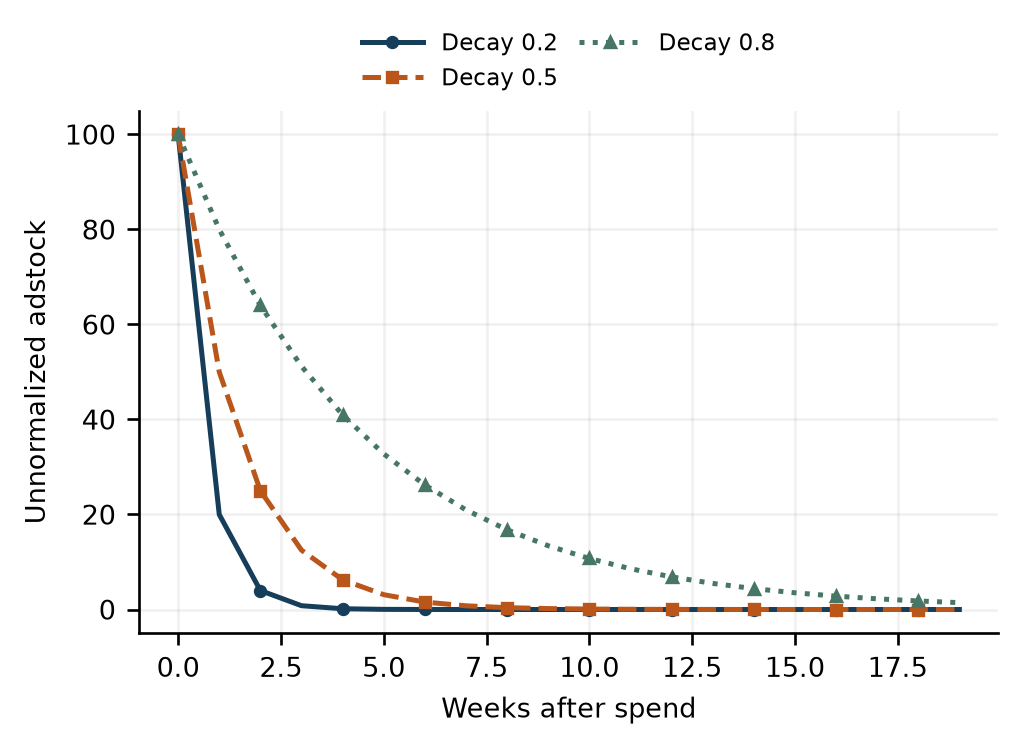

In [2]:
impulse=np.r_[100.,np.zeros(19)]; plt.figure()
for decay in [.2,.5,.8]: plt.plot(adstock(impulse,decay),label=f'Decay {decay}')
plt.xlabel('Weeks after spend'); plt.ylabel('Unnormalized adstock'); plt.legend()
save(20,1,'Advertising can carry into later periods','Synthetic single-spend impulse under three geometric decay assumptions. Unnormalized stock totals differ with decay.','## Section Four: The Methodology')

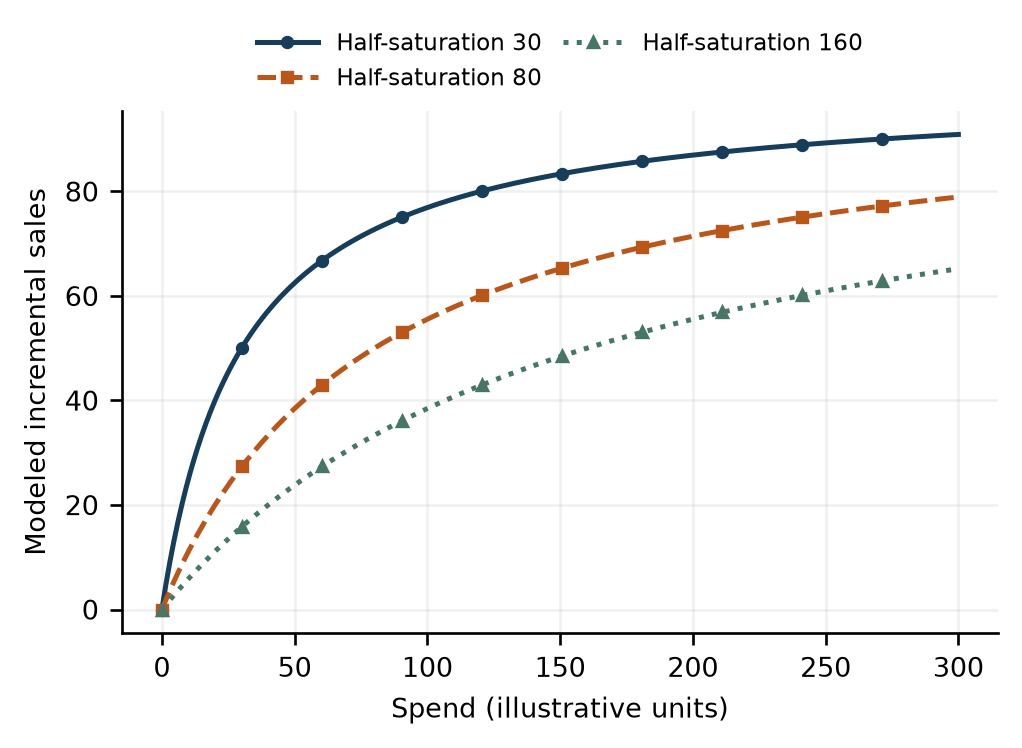

In [3]:
spend=np.linspace(0,300,200); plt.figure()
for half in [30,80,160]: plt.plot(spend,100*spend/(half+spend),label=f'Half-saturation {half}')
plt.xlabel('Spend (illustrative units)'); plt.ylabel('Modeled incremental sales'); plt.legend(fontsize=7)
save(20,2,'Marginal response declines in this model','Michaelis-Menten response curves with assumed parameters. General Hill curves with exponent above one are S-shaped, not globally concave.','## Section Four: The Methodology')

## Confounding can inflate apparent return
Demand conditions affect both spending and sales. A randomized campaign has
independent treatment; adjustment for the known confounder recovers its effect.

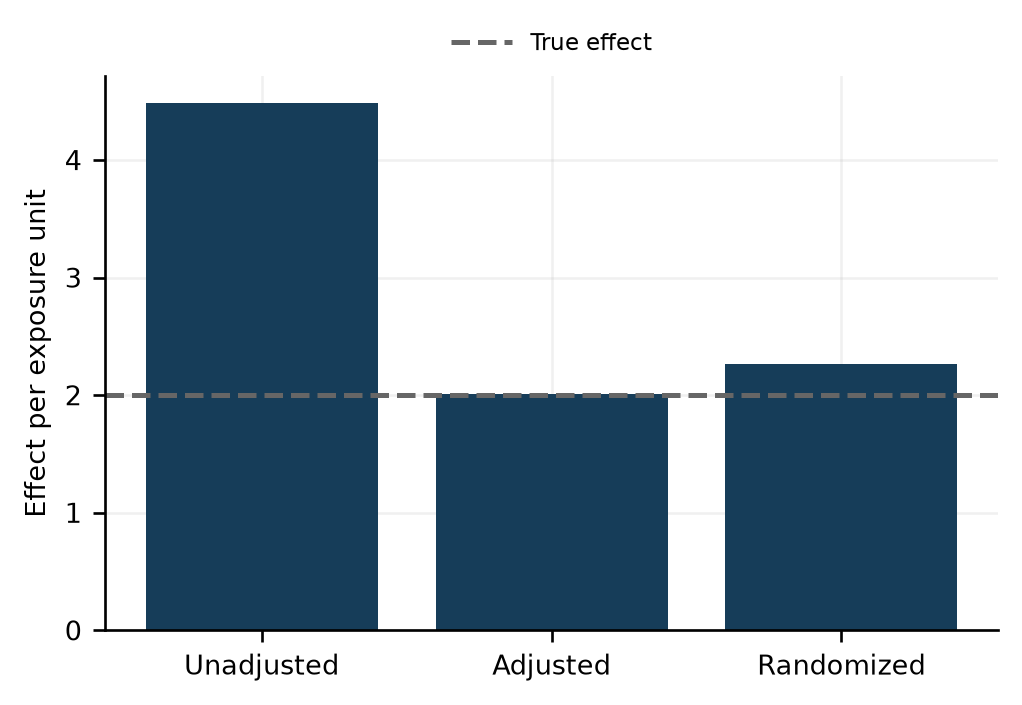

In [4]:
n=3000; demand=rng.normal(size=n); treatment=.8*demand+rng.normal(size=n); sales=2*treatment+5*demand+rng.normal(size=n)
naive=np.linalg.lstsq(np.c_[np.ones(n),treatment],sales,rcond=None)[0][1]
adjusted=np.linalg.lstsq(np.c_[np.ones(n),treatment,demand],sales,rcond=None)[0][1]
randomized=rng.binomial(1,.5,n); experiment=2*randomized+5*demand+rng.normal(size=n)
lift=experiment[randomized==1].mean()-experiment[randomized==0].mean()
plt.figure(); plt.bar(['Unadjusted','Adjusted','Randomized'],[naive,adjusted,lift]); plt.axhline(2,ls='--',color='.4',label='True effect'); plt.ylabel('Effect per exposure unit'); plt.legend()
save(20,3,'Attribution is not automatically incrementality','Known synthetic effect of two units. Observational spending shares a cause with demand; randomization and correct adjustment address that bias under this generator.','## Section Two: Geo-Experiments and the Randomized Approach')
assert abs(adjusted-2)<.15

## Fit an actual time-series marketing-mix regression
Here media spend is transformed by adstock and saturation before regression.
Two channels, a trend, and seasonal controls explain synthetic weekly sales.
Transformation parameters are fixed in advance. Spend schedules are assumed
known throughout the holdout; carrying adstock forward uses only earlier spend.
This validates prediction under a specified generator, not causal identification
in an observational business dataset with omitted confounders.

In [5]:
weeks = np.arange(180)
media_a = rng.uniform(0,100,len(weeks))
media_b = rng.uniform(0,80,len(weeks))
stock_a, stock_b = adstock(media_a,.5), adstock(media_b,.3)
response_a = stock_a/(80+stock_a)
response_b = stock_b/(50+stock_b)
design = np.column_stack([np.ones(len(weeks)), weeks/52,
                          np.sin(2*np.pi*weeks/52), np.cos(2*np.pi*weeks/52),
                          response_a, response_b])
true_coefficients = np.array([100., 3., 8., -2., 35., 20.])
weekly_sales = design@true_coefficients+rng.normal(0,2,len(weeks))
cutoff = 144
estimated = np.linalg.lstsq(design[:cutoff], weekly_sales[:cutoff], rcond=None)[0]
holdout_prediction = design[cutoff:]@estimated
baseline_prediction = weekly_sales[cutoff-52:len(weeks)-52]
assert len(holdout_prediction) == len(weekly_sales)-cutoff
print('MMM coefficients [intercept, trend, sin, cos, channel A, channel B]:', estimated)
print({'holdout_weeks': len(holdout_prediction),
       'transformed_media_MAE': mae(weekly_sales[cutoff:], holdout_prediction),
       'seasonal_naive_MAE': mae(weekly_sales[cutoff:], baseline_prediction)})
print('Causal effects require more than this temporal predictive comparison.')

MMM coefficients [intercept, trend, sin, cos, channel A, channel B]: [102.26939435   3.09008222   8.20444822  -1.84451026  32.59985804
  17.87500194]
{'holdout_weeks': 36, 'transformed_media_MAE': 1.8388053738744092, 'seasonal_naive_MAE': 5.382756681414269}
Causal effects require more than this temporal predictive comparison.


## Limits and exercise
Hide or mismeasure demand and refit. Real MMM needs temporal validation,
identification assumptions, calibration experiments and uncertainty. Robyn's
standard ridge approach is not Bayesian MMM. Do not interpret SHAP allocation
or observational response curves as experimentally identified causal effects.

## A good sales fit can hide unstable attribution
Compare expanding-window fits under highly correlated channels. The known
synthetic baseline supplies an oracle benchmark, NOT an achievable business
estimate. A deliberately wrong fixed baseline tests the proposed architecture's
weakness. Bayesian rows are exact Gaussian coefficient posteriors conditional
on a fixed baseline, known noise and fixed transforms, not full Bayesian MMM.
Priors A/B intentionally disagree; they are NOT recommendations or evidence.

                  channel_a_mean  channel_a_sd  holdout_MAE  coefficient_error
method                                                                        
Joint OLS                  2.613         2.656        1.506             13.316
Known background           2.530         2.717        1.488             13.376
Prior A                   15.837         0.070        1.499              5.440
Prior B                    3.967         0.041        1.479             11.343
Wrong background          -5.470         2.717        1.488             19.883


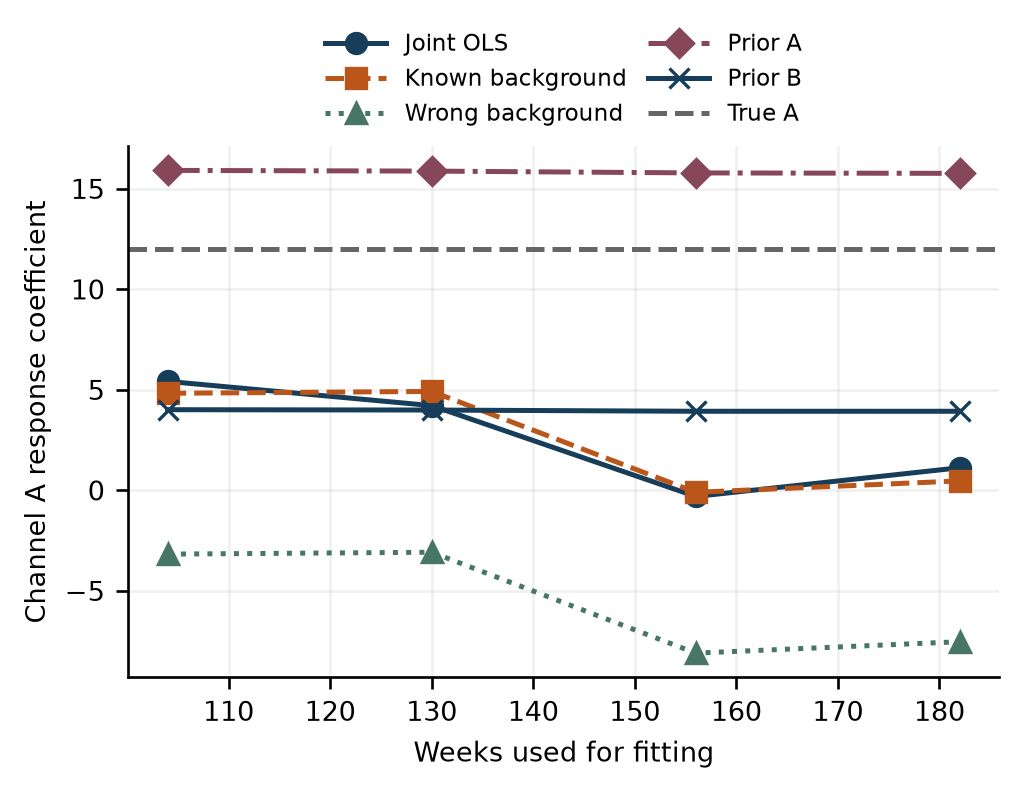

In [6]:
from forecasting_companion.practitioner import gaussian_update, adstock as stock_with_history
import pandas as pd
import os
weeks=np.arange(220); seasonal=np.sin(2*np.pi*weeks/52)
background=100+8*seasonal+.02*weeks
channel_a=2+.6*seasonal+rng.normal(0,.15,len(weeks))
channel_b=channel_a+rng.normal(0,.025,len(weeks))
media=np.c_[channel_a,channel_b]; truth=np.array([12.,8.]); noise_sd=2.
y=background+media@truth+rng.normal(0,noise_sd,len(weeks))
background_design=np.c_[np.ones(len(weeks)),seasonal,weeks]
rows=[]
for end in [104,130,156,182]:
    train=slice(0,end); test=slice(end,end+26)
    joint_design=np.c_[background_design,media]
    coefficients=np.linalg.lstsq(joint_design[train],y[train],rcond=None)[0]
    rows.append(dict(end=end,method='Joint OLS',a=coefficients[-2],b=coefficients[-1],
                     holdout_mae=mae(y[test],joint_design[test]@coefficients)))
    for name,bg in [('Known background',background),('Wrong background',background+8*channel_a)]:
        coefficients=np.linalg.lstsq(media[train],y[train]-bg[train],rcond=None)[0]
        rows.append(dict(end=end,method=name,a=coefficients[0],b=coefficients[1],
                         holdout_mae=mae(y[test],bg[test]+media[test]@coefficients)))
    for name,prior in [('Prior A',[16.,4.]),('Prior B',[4.,16.])]:
        coefficients,covariance=gaussian_update(media[train],y[train]-background[train],prior,1.,noise_sd)
        rows.append(dict(end=end,method=name,a=coefficients[0],b=coefficients[1],
                         holdout_mae=mae(y[test],background[test]+media[test]@coefficients)))
stability=pd.DataFrame(rows)
stability['coefficient_error']=np.sqrt((stability.a-12)**2+(stability.b-8)**2)
print(stability.groupby('method').agg(channel_a_mean=('a','mean'),channel_a_sd=('a','std'),
      holdout_MAE=('holdout_mae','mean'),coefficient_error=('coefficient_error','mean')).round(3).to_string())
plt.figure()
for i,(name,group) in enumerate(stability.groupby('method',sort=False)):
    plt.plot(group.end,group.a,marker=['o','s','^','D','x'][i],ls=['-','--',':','-.','-'][i],label=name)
plt.axhline(12,color='.4',ls='--',label='True A'); plt.xlabel('Weeks used for fitting'); plt.ylabel('Channel A response coefficient'); plt.legend(fontsize=5.5,ncol=2)
save(20,4,'Stable estimates can still assign the wrong credit','Synthetic correlated channels: true A=12 and B=8. Compare joint OLS, fixed correct/wrong backgrounds, and two conflicting Gaussian priors. Fixed backgrounds and priors impose assumptions; stability is not identification.','## Section Five: What the Model Can and Cannot Tell You')
folder=Path(os.environ.get('FORECAST_OUTPUT',project/'companion'))/'results'
stability.to_csv(folder/'ch20-attribution-stability.csv',index=False)

## The dataset starts; the business does not
Include prior spend when initializing adstock. The initial-state example below
compares known pre-window carryover with a zero-start error. An intercept does
not by itself recover channel-specific missing carryover. Regression can omit an
intercept, but forcing unexplained baseline sales onto media creates another bias.

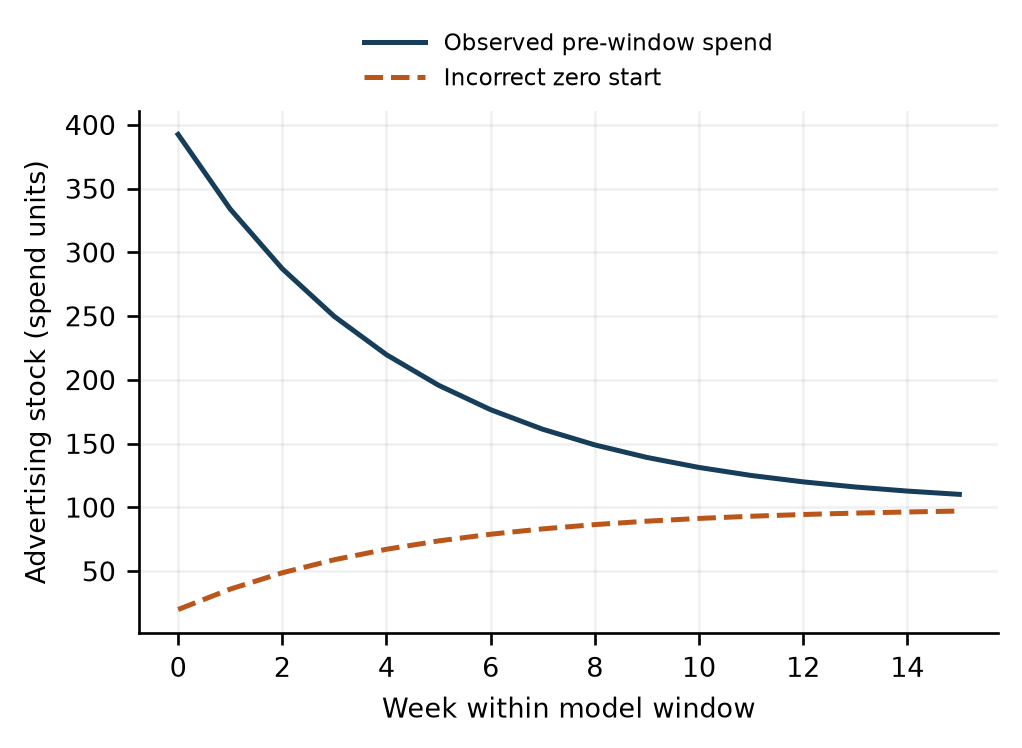

In [7]:
all_spend=np.r_[np.full(12,100.),np.full(16,20.)]
stock=stock_with_history(all_spend,.8)
with_history=stock[12:]; zero_start=stock_with_history(all_spend[12:],.8)
initialized=stock_with_history(all_spend[12:],.8,initial=stock[11])
assert np.allclose(initialized,with_history)
plt.figure(); plt.plot(with_history,label='Observed pre-window spend'); plt.plot(zero_start,'--',label='Incorrect zero start')
plt.xlabel('Week within model window'); plt.ylabel('Advertising stock (spend units)'); plt.legend(fontsize=6)
save(20,5,'Initial conditions are not an intercept','Synthetic geometric carryover includes twelve weeks before the modeled outcome window. Omitting that history creates a transient stock error; no causal attribution is established by this illustration.','## Section Four: The Methodology')

## Simulated-test-market logic is a different workflow
Small worked transfer: calibrate one scale against six established products, then
evaluate two held-out products. Here potential trials and units per trier are
independently supplied synthetic inputs; actual sales alone cannot identify both.
For a full editable reference table and research-age checks, continue in chapter 27.
The declared 24-month TRIAL total is not a first-year sales total. Gamma timing
represents awareness/distribution development once; no independent delay is added.

Synthetic held-out sales are exact because this noiseless generator is correctly specified.
 peak_month  year1_trials  year2_trials  year1_units  year2_units
          3        3593.3         406.7       7048.2       7370.7
          4        3200.0         800.0       5944.7       7455.5
          5        2852.2        1147.8       5113.4       7487.0


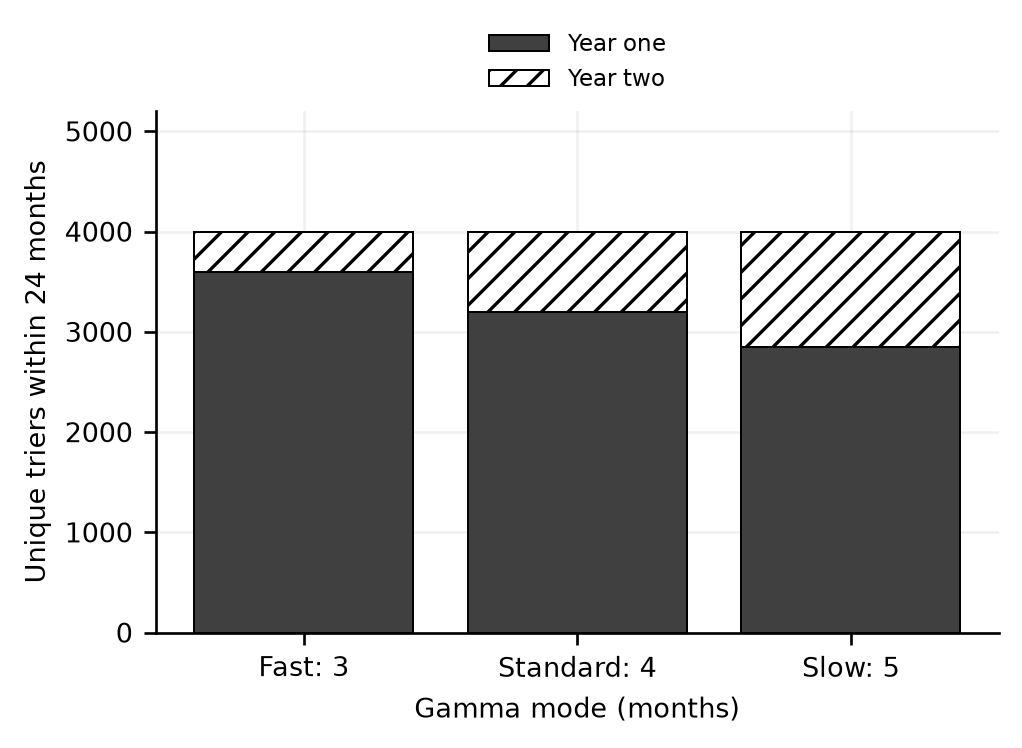

In [8]:
from forecasting_companion.practitioner import calibrate_scale, launch_trials, cohort_units
potential_trials=np.array([1000,1500,1800,2200,2700,3200,3600,4100],dtype=float)
units_per_trier=np.array([3.,4.,3.5,4.5,3.8,4.2,3.6,4.1])
known_sales=potential_trials*units_per_trier*.8
conversion=calibrate_scale((potential_trials*units_per_trier)[:6],known_sales[:6])
assert np.allclose(potential_trials[6:]*units_per_trier[6:]*conversion,known_sales[6:])
print('Synthetic held-out sales are exact because this noiseless generator is correctly specified.')
total_trials_24m=5000*conversion
launch_rows=[]
for peak in [3,4,5]:
    trial=launch_trials(total_trials_24m,peak=peak,horizon=24,denominator='horizon')
    units=cohort_units(trial,np.r_[1.,np.full(23,.15)])
    launch_rows.append(dict(peak_month=peak,year1_trials=trial[:12].sum(),year2_trials=trial[12:].sum(),
                           year1_units=units[:12].sum(),year2_units=units[12:].sum()))
launch_table=pd.DataFrame(launch_rows)
print(launch_table.round(1).to_string(index=False))
plt.figure(); plt.bar(['Fast: 3','Standard: 4','Slow: 5'],launch_table.year1_trials,label='Year one')
plt.bar(['Fast: 3','Standard: 4','Slow: 5'],launch_table.year2_trials,bottom=launch_table.year1_trials,label='Year two')
plt.xlabel('Gamma mode (months)'); plt.ylabel('Unique triers within 24 months'); plt.ylim(0,total_trials_24m*1.3); plt.legend(fontsize=7,ncol=2,loc='upper center')
save(20,6,'Launch speed changes the first-year share','Illustrative 4,000-trier total over 24 months. The standard gamma allocates 80% to year one; faster/slower timing changes that share. Trial timing is not a total-sales curve.','## Section Three: Simulated Test Markets')
launch_table.to_csv(folder/'ch20-launch-trial-and-volume.csv',index=False)

## The test market you never run
The author's desk model replaces every panel measurement with a derived default:
trial from seven judged attributes, awareness from a media plan, repeat from the
category purchase cycle, build speed from a menu. Every weight and curve constant
in `reconcile_sim` is an illustrative starting value from no particular source;
readers should tune them to launches they know or fit them to their own history.
The model then checks whether the typed inputs agree with each other (the
Implication column) and runs the forecast two ways. Agreement is coherence among
judgments, not evidence about the launch.

index 35.9 (after intercept) -> trial 23.3%; awareness 24.8%
bottom-up 3.545 MM units, top-down 3.525 MM units, gap 0.56%, $14.15 MM


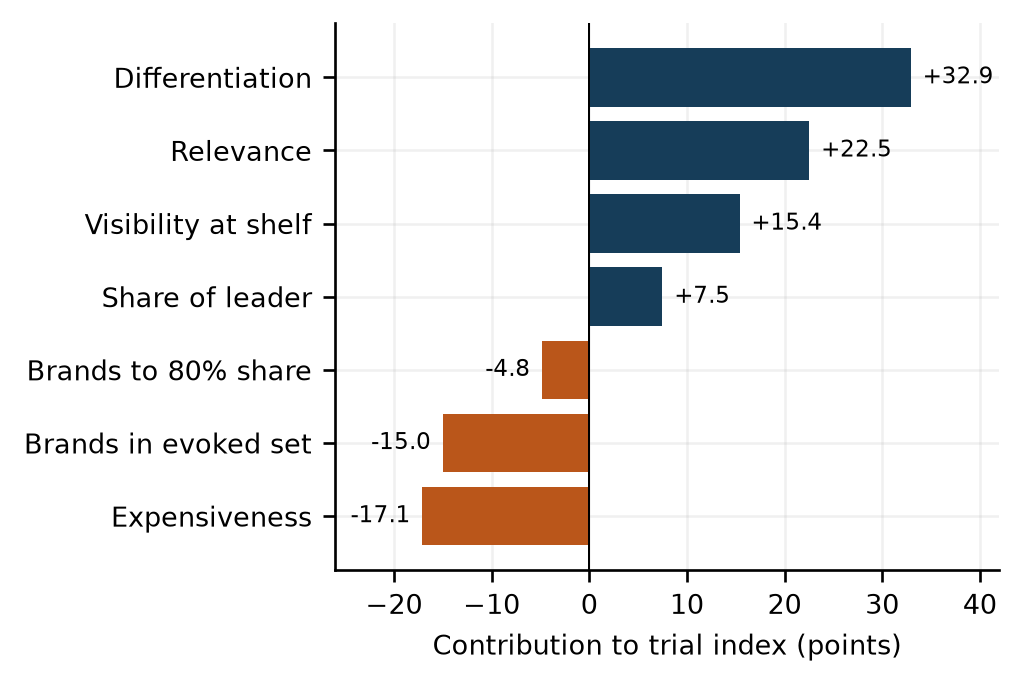

 pass_number  typed_frequency  implied_frequency  typed_penetration  implied_penetration  typed_market_size  implied_market_size  units_mm  dollars_mm   gap
           0           20.000             11.921              0.530                0.527              415.0              655.836     3.545      14.146 0.006
           1           11.921             12.000              0.527                0.527              415.0              412.663     3.451      13.768 0.000
           2           12.000             12.000              0.527                0.527              415.0              415.000     3.451      13.771 0.000


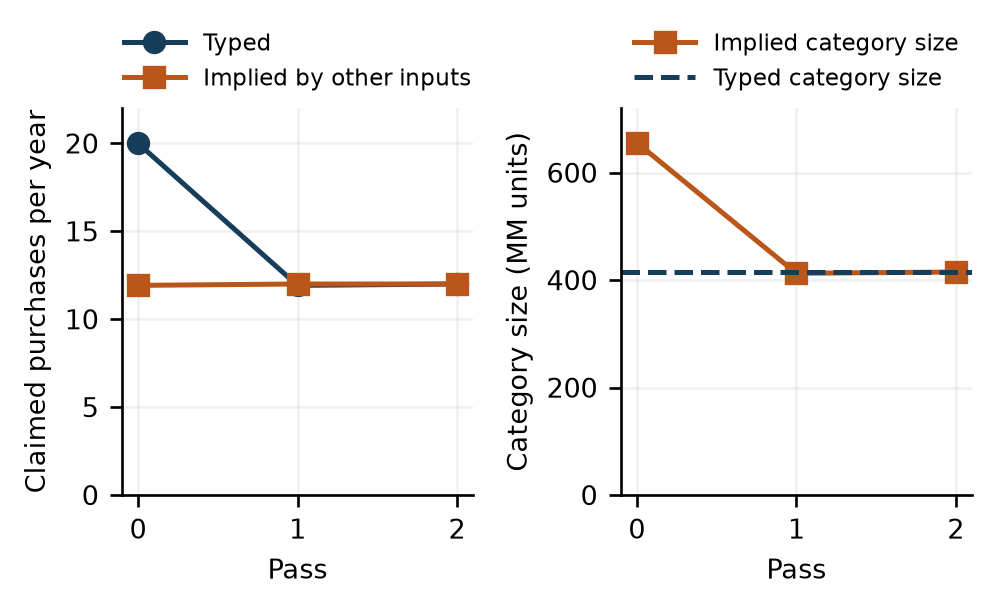

In [9]:
from forecasting_companion import reconcile_sim as rs
desk=rs.run(); r=desk.resolved
contrib=pd.Series(r.trial_contributions).sort_values()
labels={'differentiation':'Differentiation','relevance':'Relevance','share_of_leader':'Share of leader',
        'visibility':'Visibility at shelf','brands_at_80_share':'Brands to 80% share',
        'brands_in_evoked_set':'Brands in evoked set','expensiveness':'Expensiveness'}
print(f'index {r.trial_index:.1f} (after intercept) -> trial {r.trial:.1%}; awareness {r.awareness:.1%}')
print(f'bottom-up {desk.units_mm[0]:.3f} MM units, top-down {desk.units_mm[1]:.3f} MM units, gap {desk.gap:.2%}, ${desk.dollars_mm[0]:.2f} MM')
assert 0.2<r.trial<0.3 and desk.gap<0.10
plt.figure(figsize=(4.3,2.9))
colors=['#ba561a' if v<0 else '#163d59' for v in contrib]
plt.barh([labels[k] for k in contrib.index],contrib.values,color=colors)
plt.axvline(0,color='black',lw=.6)
for y,v in enumerate(contrib.values): plt.text(v+(1.2 if v>0 else -1.2),y,f'{v:+.1f}',va='center',ha='left' if v>0 else 'right',fontsize=7)
plt.xlim(-26,42); plt.xlabel('Contribution to trial index (points)')
save(20,7,'Where the trial estimate comes from','Seven judged attribute scores times illustrative weights. Negative terms are shaded. Per point of score, the evoked-set weight is by far the heaviest; at these scores it and expensiveness carry the downside. Weights are generic starting values, not fitted estimates; the net index gives a 23% trial rate.','## Section Three: Simulated Test Markets')
history=rs.iterate()
loop=pd.DataFrame([dict(pass_number=i,typed_frequency=h.category_purchases_per_year,implied_frequency=d.implied_frequency,
    typed_penetration=h.category_penetration,implied_penetration=d.implied_penetration,typed_market_size=h.market_size_mm_volume,
    implied_market_size=d.implied_market_size,units_mm=d.units_mm[0],dollars_mm=d.dollars_mm[0],gap=d.gap) for i,(h,d) in enumerate(history)])
print(loop.round(3).to_string(index=False))
assert len(loop)<=4 and loop.gap.iloc[-1]<1e-6
fig,ax=plt.subplots(1,2,figsize=(4.3,2.6))
ax[0].plot(loop.pass_number,loop.typed_frequency,marker='o',label='Typed')
ax[0].plot(loop.pass_number,loop.implied_frequency,marker='s',label='Implied by other inputs')
ax[0].set_xticks(loop.pass_number); ax[0].set_xlabel('Pass'); ax[0].set_ylabel('Claimed purchases per year'); ax[0].set_ylim(0,22)
ax[0].legend(fontsize=6,frameon=False,loc='upper right')
ax[1].plot(loop.pass_number,loop.implied_market_size,marker='s',color='#ba561a',label='Implied category size')
ax[1].axhline(loop.typed_market_size.iloc[0],color='#163d59',ls='--',label='Typed category size')
ax[1].set_xticks(loop.pass_number); ax[1].set_xlabel('Pass'); ax[1].set_ylabel('Category size (MM units)'); ax[1].set_ylim(0,720)
ax[1].legend(fontsize=6,frameon=False,loc='upper right')
save(20,8,'The inputs are made to agree with each other','Copying implied values back into the typed inputs. The claimed purchase frequency falls from 20 to 12 in two passes and the implied category size meets the typed 415 million units. This is a coherence check on judgments, not evidence about the launch.','## Section Three: Simulated Test Markets',fig=fig)
loop.to_csv(folder/'ch20-desk-model-reconciliation.csv',index=False)
pd.DataFrame(rs.chain_table(desk),columns=['step','value','source']).to_csv(folder/'ch20-desk-model-chain.csv',index=False)

## Decision checks
Compare prediction error AND attribution stability across refits, background
assumptions and priors. An oracle baseline is not a practical estimator; estimate
a real baseline from justified earlier/external evidence and propagate uncertainty.
Merely deseasonalizing sales can remove marketing signal: if nuisance effects are
estimated from the same data, appropriate residualization must also handle media.
Confounders cannot be discarded just to obtain stable coefficients. Report a
conditional scenario unless observational identification is defensible; use a
feasible, informative experiment when the decision needs stronger causal evidence.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular series of `sales` with one nonnegative spend column per channel and any numeric control columns (weather, price, competitor activity). Name the channels in config `channels` and the controls in `controls`. The older two-channel example (`spend_a,spend_b` with fixed `decay_a`, `half_a`, ...) still runs unchanged.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,sales,tv,digital,radio,temp
2010-01-01,131.2,54.0,22.5,8.1,-0.4
2010-02-01,128.7,61.3,19.0,12.6,0.2
2010-03-01,140.9,12.8,70.4,3.3,1.1
```

## Explain the mechanism

Carryover changes when spend can matter; saturation changes marginal response. Neither transformation resolves why spend was high when demand was high. Attribution is a decomposition conditional on a model, whereas incrementality asks what would happen under a different intervention.

## Work through the arithmetic

Geometric stock a[t]=spend[t]+.5a[t-1] with initial stock 20 and new spend 100 gives 110, not 100. At half-saturation 100, response a/(100+a) is 110/210=.52381. A zero-start assumption gives .5 and shifts the explanatory feature even before regression.

## Adapt the lesson to reader data

Replace weekly sales and media construction with synchronized observed series and documented controls. Obtain pre-window spend to initialize stock. Keep the confounding experiment and prior-stability experiment as separate controlled illustrations rather than mixing their synthetic truths into business estimation.

For this chapter, settle these questions before fitting: Is the question predictive sales, incremental effect or launch volume? What pre-window spend exists? Which demand drivers affect both spend and sales? What experimental calibration or defensible external priors exist?

## Interpret the actual lesson outputs

The lesson executes a transformed two-channel regression, then distinct attribution-stability and initial-state experiments. Gaussian posterior rows condition on fixed background, transforms and noise; they are not full Bayesian MMM. The oracle baseline is known only in simulation. Launch timing is a separate workflow with chapter-27 transfer safeguards.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,actual,prediction,baseline`.
- `summary.json`: `channels,controls,selected,alpha,coefficients,condition_number,test_mae,baseline_mae,response_curves,marginal_roas,refits,posterior,reallocation,origins` plus method, interpretation, assumptions, not_done and status.

For every channel the tool builds a geometric adstock and a saturation transform (`hill`, `log`, `negexp`, `none`, or `auto` to choose among them), choosing each channel's decay from `decay_grid` and the saturation kind on `origins` earlier blocks by predictive MAE, never on the holdout; the saturation scale is fixed on training data. It fits sales on trend, one seasonal harmonic, the transformed channels and standardised controls by closed-form ridge (`alpha`, penalising channel and control columns only), scores the untouched holdout against seasonal naive, and returns response curves and marginal response at current spend per channel, coefficient refits across `windows` expanding windows (attribution stability), an optional Gaussian posterior on the channel coefficients when `prior_mean` and `prior_sd` are supplied, and a budget reallocation that equalises marginal response under `reallocation_total`, labelled a conditional scenario. No experiment is used; coefficients are a fitted decomposition, not identified causal effects. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

An accurate total forecast can hide unstable channel coefficients; a fixed but wrong baseline can produce stable wrong attribution. Keep initial stock separate from the intercept. Sensitivity to correlated media, priors and nuisance components belongs in the result.

Without pre-window history, vary initial stocks and disclose transient uncertainty. Without credible confounder or experiment evidence, do not infer incrementality. With missing channels or inconsistent currencies, narrow the scope rather than quietly assigning residual sales to observed media.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,actual,prediction,baseline`; `summary.json` keys: `channels,controls,selected,alpha,coefficients,condition_number,test_mae,baseline_mae,response_curves,marginal_roas,refits,posterior,reallocation,origins` plus method, interpretation, assumptions, not_done and status. Report the refit table beside the coefficients; a channel whose coefficient halves when the window moves has not been attributed, whatever the point estimate says.

## Three exercises with worked solutions

### Exercise 1

Decay .8, previous stock 50, current spend 10: new stock?

**Worked solution.** 10+.8×50=50.

### Exercise 2

A fixed baseline stabilizes channel coefficients but has no external support. Has identification improved?

**Worked solution.** Not established. The coefficients may be stably biased; test plausible backgrounds and seek stronger identification evidence.

### Exercise 3

A response curve has Hill exponent 2. Must it be globally concave?

**Worked solution.** No. It can be S-shaped; do not impose a universal diminishing-return interpretation over its full range.

## Business-reader application

Use this request with the skill:

> Apply chapter 20 to weekly_media.csv, account for initial carryover, evaluate sales prediction and attribution stability, and label which spending claims remain conditional.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [10]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch20.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch20.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(20, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch20-workshop-results.csv', index=False)
_ = (workshop_output/'ch20-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Adstock and saturation MMM with ridge fit and rolling-origin selection
Status: passed

Interpretation: 2-channel MMM (log saturation, decays {'spend_a': 0.3, 'spend_b': 0.7}) holdout MAE 1.834 vs seasonal naive 3.991. Marginal response at current spend: spend_a 0.123, spend_b 0.0966. Refits across 3 windows show how stable the channel coefficients are; instability is a warning about attribution, not about prediction.

Assumptions:
  - Spend schedules known for the holdout
  - Geometric carryover with the selected decays
  - log saturation scaled on training data
  - Trend and one seasonal harmonic as background
Not done:
  - Causal identification: coefficients are a fitted decomposition; confounding by unobserved demand drivers remains
  - No geo or holdout experiment was used to calibrate the response curves
  - No priors supplied (prior_mean, prior_sd); ridge only

Evidence:
  channels: [spend_a, spend_b]
  controls: []
  selected: <3 entries>
  alpha: 1
  coefficients: inter